# Deconvolution - Increase in runtime due to extra padding


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [78]:
from src.GenomeDeconvolution import GenomeDeconvolution

outdir = "output/test"
genome_deconvolution = GenomeDeconvolution(save_dir=outdir)

In [89]:
genome_deconvolution.load_chrom_span(1, (10000, 11000))

Already loaded chromosome reads for 1. Using cache.
Applying a normalization for length distribution
Already loaded chromosome reads for 1. Using cache.
Applying a normalization for length distribution


In [90]:
genome_deconvolution.combined_model.deconvolve()

Deconvolving combined model with gamma=0.1
Deconvolving bin size: 10x10
of G shape: (31, 2600)
Padding type: both
Deconvolving with gamma=0.1
0/2600 - 00:00:00.123
500/2600 - 00:00:58.219
1000/2600 - 00:01:52.995
1500/2600 - 00:02:46.950
2000/2600 - 00:03:40.986
2500/2600 - 00:04:35.117
Deconvolved in : 00:04:47.416
The fitting norm is 1.45, the smoothing norm is: 2.20


In [91]:
from src.config import load_configs_by_config_type
config, _ = load_configs_by_config_type('shared')
t_indices = config.get_Hpositions_for_branch('t')
i_indices = config.get_Hpositions_for_branch('i')

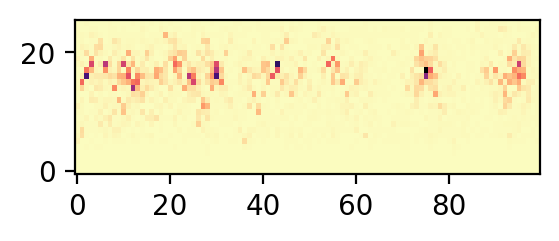

In [98]:
f = genome_deconvolution.combined_model.deconvolved_f_value
f_imgs = f.reshape((f.shape[0], 26, -1))
plt.figure(figsize=(3, 1))
plt.imshow(f_imgs[0], cmap='magma_r', vmin=0.7, origin='lower', aspect='auto')


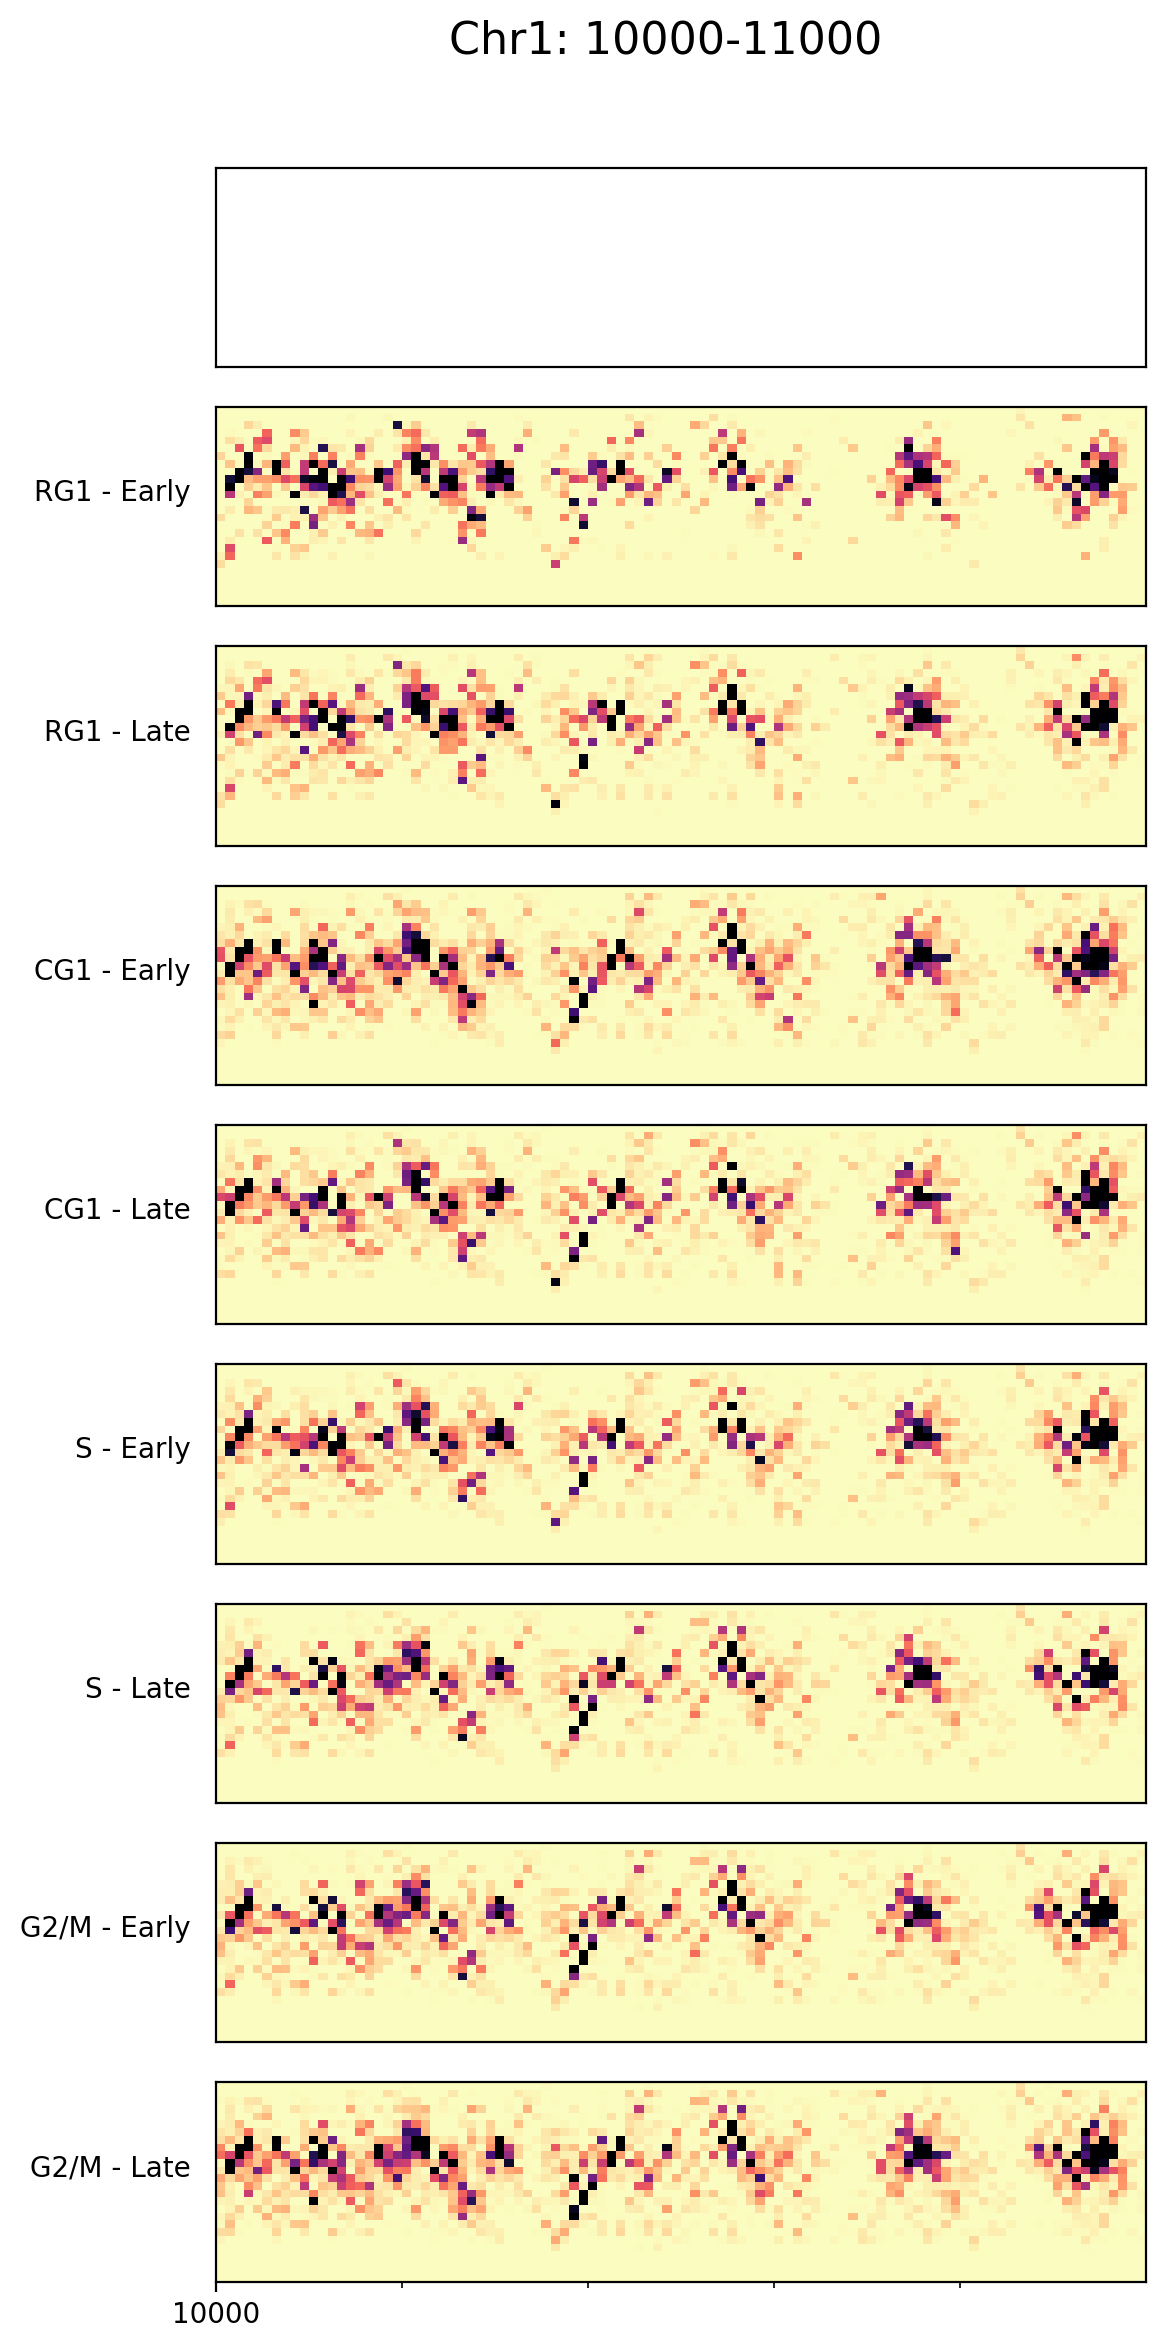

In [102]:
fig = genome_deconvolution.plot_deconvolved_result(figwidth=6)

(0.0, 2.0)

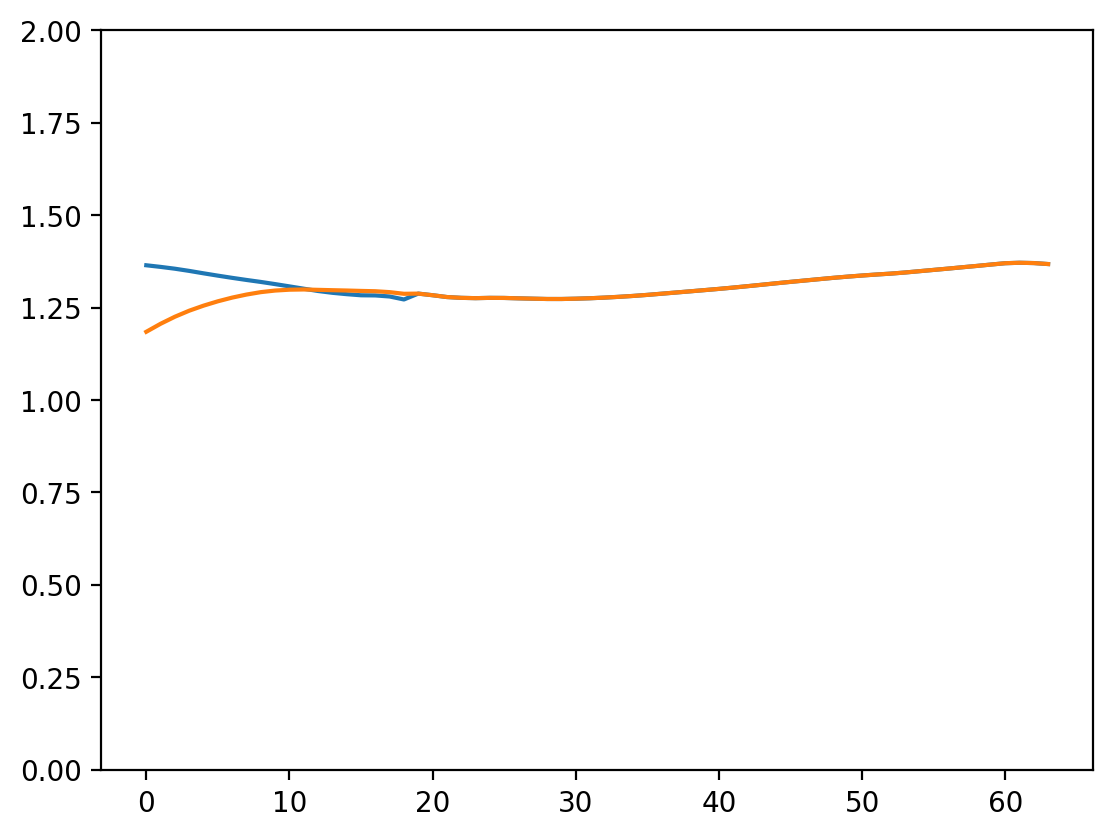

In [94]:
plt.plot(genome_deconvolution.combined_model.deconvolved_f_value.mean(axis=1)[t_indices])
plt.plot(genome_deconvolution.combined_model.deconvolved_f_value.mean(axis=1)[i_indices])
plt.ylim(0, 2)

In [104]:
from src.create_models import create_wt1_model, create_wt2_model, SHORTENED_G1_LENGTH, SHORTENED_POSTG1_LENGTH

create_wt1_model('models/yl_cell_cycle/wt1_rg1_shortened.22.label', g1_length=SHORTENED_G1_LENGTH,
                postg1_length=SHORTENED_POSTG1_LENGTH)
create_wt2_model('models/yl_cell_cycle/wt2_rg1_shortened.20.label', g1_length=SHORTENED_G1_LENGTH,
                postg1_length=SHORTENED_POSTG1_LENGTH)


Created model and saved to file: models/yl_cell_cycle/wt1_rg1_shortened.22.label
Created model and saved to file: models/yl_cell_cycle/wt2_rg1_shortened.20.label


'models/yl_cell_cycle/wt2_rg1_shortened.20.label'

In [105]:
from src.model import Model
from src.config import load_combined_gene_expression_by_config_type

combined_model = load_combined_gene_expression_by_config_type('shared')
model = Model(combined_model, 'CLB2')


In [106]:
model.deconvolve_find_optimal_gamma()

In [107]:
model.gamma = 0.03
model.deconvolve()

In [ ]:
fig = model.plot_deconvolved_gene()

In [ ]:
model.config.get_phase_timepoints_for_phase('CG1')

In [ ]:
model.config.get_phase_timepoints_for_phase('postG1')